# Phase 1 — Data Exploration

Exploring the StatsBomb 360 shots we pulled into `data/processed/shots.parquet`.
Each row is one shot: the locked `GameState` (serialized), the goal/no-goal label,
StatsBomb's own xG (a benchmark), and metadata.

Goals here: understand the base goal rate, where shots come from, what a freeze
frame actually looks like, and how well-calibrated StatsBomb's xG is (a preview of
the yardstick our own model must meet).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make `import xg` work from the notebooks/ directory.
sys.path.insert(0, str(Path.cwd().parent / "src"))
from xg.data.schema import GameState, PITCH_LENGTH, PITCH_WIDTH, GOAL_POST_LEFT, GOAL_POST_RIGHT

df = pd.read_parquet(Path.cwd().parent / "data" / "processed" / "shots.parquet")
print(df.shape)
df.head(3)

Matplotlib is building the font cache; this may take a moment.


(2783, 12)


,competition,match_id,minute,team,player,shot_type,body_part,outcome,is_goal,statsbomb_xg,n_players_visible,game_state
0,World Cup 2022,3857276,2,Canada,Mark Anthony Kaye,Open Play,Left Foot,Blocked,0,0.038882,19,"{""shot_xy"":[96.5,40.7],""players"":[{""xy"":[108.6..."
1,World Cup 2022,3857276,3,Morocco,Hakim Ziyech,Open Play,Left Foot,Goal,1,0.024477,8,"{""shot_xy"":[83.9,45.0],""players"":[{""xy"":[78.5,..."
2,World Cup 2022,3857276,8,Morocco,Abdelhamid Sabiri,Free Kick,Right Foot,Blocked,0,0.022070,20,"{""shot_xy"":[86.8,38.4],""players"":[{""xy"":[96.7,..."


## Base rates and shot types

The overall conversion rate is the number every xG model is implicitly trying to
predict on average. Note how penalties sit far above everything else.

In [2]:
print(f"Overall goal rate: {df['is_goal'].mean():.1%}\n")
conv = df.groupby('shot_type').agg(n=('is_goal', 'size'), goal_rate=('is_goal', 'mean'))
conv.sort_values('n', ascending=False)

Overall goal rate: 12.6%



,n,goal_rate
shot_type,,
Open Play,2575,0.105243
Penalty,119,0.638655
Free Kick,87,0.034483
Corner,2,0.000000


## Where do shots (and goals) come from?

Plotting every shot on the attacking third. Goals in one colour, misses in another.
The pattern that should jump out: goals cluster centrally and close to goal — the
geometry that distance + angle features will capture in Phase 2.

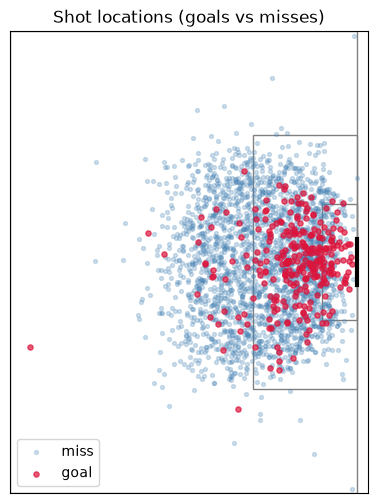

In [3]:
def draw_pitch(ax):
    """Draw the attacking half (x from 60 to 120) with the goal at x=120."""
    ax.add_patch(plt.Rectangle((60, 0), 60, PITCH_WIDTH, fill=False, ec='gray'))
    # 18-yard box and goal
    ax.add_patch(plt.Rectangle((102, 18), 18, 44, fill=False, ec='gray'))
    ax.add_patch(plt.Rectangle((114, 30), 6, 20, fill=False, ec='gray'))
    ax.plot([GOAL_POST_LEFT[0], GOAL_POST_RIGHT[0]],
            [GOAL_POST_LEFT[1], GOAL_POST_RIGHT[1]], 'k-', lw=3)
    ax.set_xlim(60, 122); ax.set_ylim(0, PITCH_WIDTH)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

xy = np.array([json.loads(g)['shot_xy'] for g in df['game_state']])
goal = df['is_goal'].values.astype(bool)

fig, ax = plt.subplots(figsize=(8, 6))
draw_pitch(ax)
ax.scatter(xy[~goal, 0], xy[~goal, 1], s=8, alpha=0.25, c='steelblue', label='miss')
ax.scatter(xy[goal, 0], xy[goal, 1], s=14, alpha=0.7, c='crimson', label='goal')
ax.legend(loc='lower left'); ax.set_title('Shot locations (goals vs misses)')
plt.show()

## What a freeze frame looks like

Reconstructing one `GameState` and drawing every visible player. This is the
positional context our model gets to use beyond simple distance/angle: defenders
in the way, the keeper's position, attacking support.

Jude Bellingham | Open Play | StatsBomb xG=0.08


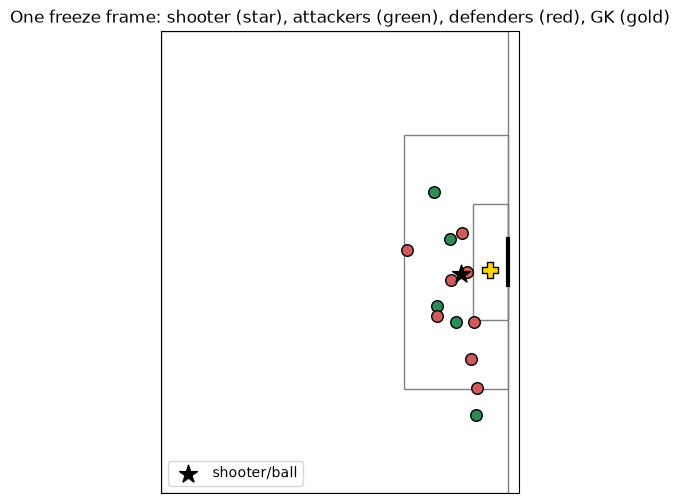

In [4]:
# Pick a goal with a rich freeze frame to visualise.
idx = df[(df['is_goal'] == 1) & (df['n_players_visible'] >= 12)].index[0]
state = GameState.model_validate_json(df.loc[idx, 'game_state'])
print(f"{df.loc[idx, 'player']} | {df.loc[idx, 'shot_type']} | StatsBomb xG={df.loc[idx, 'statsbomb_xg']:.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
draw_pitch(ax)
for p in state.players:
    if p.is_gk:
        ax.scatter(*p.xy, s=120, c='gold', edgecolors='k', marker='P', zorder=3)
    else:
        c = 'seagreen' if p.team == 'att' else 'indianred'
        ax.scatter(*p.xy, s=70, c=c, edgecolors='k', zorder=2)
ax.scatter(*state.shot_xy, s=180, c='black', marker='*', zorder=4, label='shooter/ball')
ax.legend(loc='lower left')
ax.set_title('One freeze frame: shooter (star), attackers (green), defenders (red), GK (gold)')
plt.show()

## How good is StatsBomb's own xG? (the bar we must clear)

Binning shots by their StatsBomb xG and comparing to the actual goal rate in each
bin is a calibration check. A perfectly calibrated model hugs the diagonal: shots
rated 0.3 go in ~30% of the time. This previews the calibration analysis we'll do
on our own model in Phase 5.

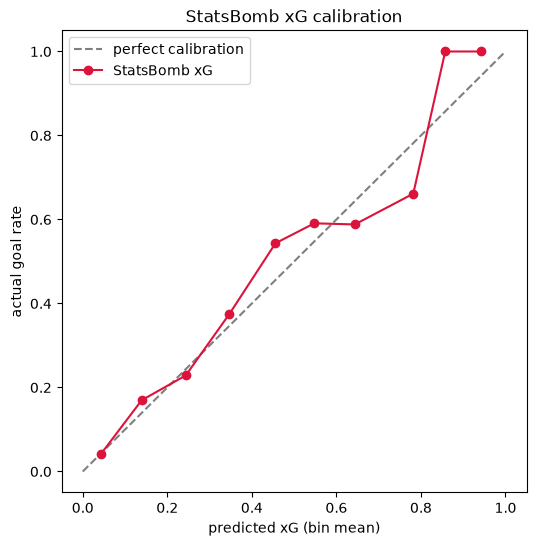

,pred,actual,n
xg_bin,,,
"(0.0, 0.1]",0.043540,0.042347,1960
"(0.1, 0.2]",0.139484,0.169713,383
"(0.2, 0.3]",0.243649,0.228758,153
"(0.3, 0.4]",0.346878,0.375000,64
"(0.4, 0.5]",0.455946,0.543478,46
"(0.5, 0.6]",0.547823,0.590909,22
"(0.6, 0.7]",0.643705,0.588235,17
"(0.7, 0.8]",0.781887,0.661417,127
"(0.8, 0.9]",0.857456,1.000000,8


In [5]:
bins = np.linspace(0, 1, 11)
df['xg_bin'] = pd.cut(df['statsbomb_xg'], bins)
cal = df.groupby('xg_bin', observed=True).agg(pred=('statsbomb_xg', 'mean'),
                                              actual=('is_goal', 'mean'), n=('is_goal', 'size'))
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect calibration')
ax.plot(cal['pred'], cal['actual'], 'o-', c='crimson', label='StatsBomb xG')
ax.set_xlabel('predicted xG (bin mean)'); ax.set_ylabel('actual goal rate')
ax.set_title('StatsBomb xG calibration'); ax.legend()
plt.show()
cal